In [1]:
import numpy as np
import os
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

def load_and_flatten(directory):
    images, labels = [], []
    classes = sorted(os.listdir(directory))
    for i, label in enumerate(classes):
        path = os.path.join(directory, label)
        for img_name in os.listdir(path):
            img = tf.keras.utils.load_img(os.path.join(path, img_name), 
                                         color_mode="grayscale", target_size=(48,48))
            images.append(tf.keras.utils.img_to_array(img).flatten())
            labels.append(i)
    return np.array(images) / 255.0, np.array(labels), classes

X_train_flat, y_train, class_names = load_and_flatten('archive/train')
X_test_flat, y_test, _ = load_and_flatten('archive/test')

# Calculate Class Weights to fix the 31% accuracy "short-cut"
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
dict_weights = dict(enumerate(weights))

print(f"Weights calculated: {dict_weights}")

Weights calculated: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardize the raw pixel data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# 2. PCA with 512 components and Whitening
# Whitening is the "secret" to stopping the constant 'Angry' predictions
pca = PCA(n_components=512, whiten=True)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 3. Reshape to 16x32 for the CNN
X_train_cnn = X_train_pca.reshape(-1, 16, 32, 1)
X_test_cnn = X_test_pca.reshape(-1, 16, 32, 1)

print(f"Data ready: {X_train_cnn.shape[1:]} shape")

Data ready: (16, 32, 1) shape


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

no_of_classes = 7

model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), padding='same', input_shape=(16, 32, 1)))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2)) # Lower dropout at the start to help it learn

# Block 2
model.add(Conv2D(128, (5,5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block 3
model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Block 4
model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(Dropout(0.2))

model.add(Flatten())

# Fully connected layers
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(Dropout(0.5))

model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('elu'))
model.add(Dropout(0.5))

model.add(Dense(no_of_classes, activation='softmax'))

# Reset learning rate to 0.001 to "kickstart" the learning
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

d:\Projects\Pattern Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 16, 128)     │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 16, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 8, 512)      │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,347,655 (16.58 MB)

 Trainable params: 4,343,687 (16.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Saves the version with the best val_accuracy
checkpointer = ModelCheckpoint(
    'improved_model.h5', 
    verbose=1, 
    save_best_only=True, 
    monitor='val_accuracy'
)

# More patient reducer: factor 0.5 gives it more "power" than 0.2
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
    X_train_cnn, y_train, 
    validation_data=(X_test_cnn, y_test), 
    epochs=50, 
    batch_size=64, 
    class_weight=dict_weights, 
    callbacks=[checkpointer, reduce_lr] 
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.1424 - loss: 2.4418
Epoch 1: val_accuracy improved from None to 0.11925, saving model to improved_model.h5



Epoch 1: finished saving model to improved_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 223ms/step - accuracy: 0.1438 - loss: 2.3094 - val_accuracy: 0.1193 - val_loss: 1.9515 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.1448 - loss: 2.0875
Epoch 2: val_accuracy improved from 0.11925 to 0.17400, saving model to improved_model.h5



Epoch 2: finished saving model to improved_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 222ms/step - accuracy: 0.1397 - loss: 2.0638 - val_accuracy: 0.1740 - val_loss: 1.9216 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.1511 - loss: 1.9866
Epoch 3: val_accuracy did not improve from 0.17400
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 225ms/step - accuracy: 0.1463 - loss: 1.9973 - val_accuracy: 0.1074 - val_loss: 2.0022 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.1466 - loss: 1.9453
Epoch 4: val_accuracy did not improve from 0.17400
449/449 ━━━━━━━━━━━━━━━━━━━━ 97s 217ms/step - accuracy: 0.1515 - loss: 1.9358 - val_accuracy: 0.1441 - val_loss: 1.9464 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.1553 - loss: 1.8893
Epoch 5: val_accuracy did not improve from 0.17400
449/449 ━━━━━━━━━━━━━━━━━━━━ 98s 219ms/step - accuracy: 0.1593 - loss: 1.8828 - val_accuracy: 0.


Epoch 6: finished saving model to improved_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 220ms/step - accuracy: 0.1732 - loss: 1.8033 - val_accuracy: 0.1865 - val_loss: 1.8478 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.1926 - loss: 1.7151
Epoch 7: val_accuracy improved from 0.18654 to 0.21482, saving model to improved_model.h5



Epoch 7: finished saving model to improved_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 220ms/step - accuracy: 0.1917 - loss: 1.7332 - val_accuracy: 0.2148 - val_loss: 1.8441 - learning_rate: 0.0010
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2041 - loss: 1.6747
Epoch 8: val_accuracy improved from 0.21482 to 0.25188, saving model to improved_model.h5


...


Epoch 19: finished saving model to improved_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 225ms/step - accuracy: 0.4148 - loss: 1.2042 - val_accuracy: 0.3416 - val_loss: 1.7329 - learning_rate: 5.0000e-04
Epoch 20/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.4335 - loss: 1.1568
Epoch 20: val_accuracy improved from 0.34160 to 0.34884, saving model to improved_model.h5



Epoch 20: finished saving model to improved_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 224ms/step - accuracy: 0.4368 - loss: 1.1599 - val_accuracy: 0.3488 - val_loss: 1.7576 - learning_rate: 5.0000e-04
Epoch 21/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.4640 - loss: 1.1131
Epoch 21: val_accuracy did not improve from 0.34884
449/449 ━━━━━━━━━━━━━━━━━━━━ 107s 237ms/step - accuracy: 0.4619 - loss: 1.1230 - val_accuracy: 0.3363 - val_loss: 1.7689 - learning_rate: 5.0000e-04
Epoch 22/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.4906 - loss: 1.0694
Epoch 22: val_accuracy did not improve from 0.34884
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 234ms/step - accuracy: 0.4862 - loss: 1.0777 - val_accuracy: 0.3398 - val_loss: 1.8038 - learning_rate: 5.0000e-04
Epoch 23/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.5098 - loss: 1.0288
Epoch 23: val_accuracy improved from 0.34884 to 0.35665, saving model to improved_model.h5



Epoch 23: finished saving model to improved_model.h5

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
449/449 ━━━━━━━━━━━━━━━━━━━━ 102s 228ms/step - accuracy: 0.5101 - loss: 1.0321 - val_accuracy: 0.3566 - val_loss: 1.8087 - learning_rate: 5.0000e-04
Epoch 24/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5461 - loss: 0.9624
Epoch 24: val_accuracy did not improve from 0.35665
449/449 ━━━━━━━━━━━━━━━━━━━━ 95s 213ms/step - accuracy: 0.5439 - loss: 0.9652 - val_accuracy: 0.3424 - val_loss: 1.8604 - learning_rate: 2.5000e-04
Epoch 25/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5771 - loss: 0.9060
Epoch 25: val_accuracy did not improve from 0.35665
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 221ms/step - accuracy: 0.5745 - loss: 0.9147 - val_accuracy: 0.3429 - val_loss: 1.8996 - learning_rate: 2.5000e-04
Epoch 26/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5862 - loss: 0.8857
Epoch 26: val_accuracy did not improve from 0.35665


Epoch 43: finished saving model to improved_model.h5

Epoch 43: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
449/449 ━━━━━━━━━━━━━━━━━━━━ 103s 230ms/step - accuracy: 0.7214 - loss: 0.6140 - val_accuracy: 0.3582 - val_loss: 2.1932 - learning_rate: 3.1250e-05
Epoch 44/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7256 - loss: 0.6038
Epoch 44: val_accuracy did not improve from 0.35818
449/449 ━━━━━━━━━━━━━━━━━━━━ 102s 228ms/step - accuracy: 0.7244 - loss: 0.6009 - val_accuracy: 0.3554 - val_loss: 2.2078 - learning_rate: 1.5625e-05
Epoch 45/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7228 - loss: 0.6029
Epoch 45: val_accuracy did not improve from 0.35818
449/449 ━━━━━━━━━━━━━━━━━━━━ 102s 228ms/step - accuracy: 0.7241 - loss: 0.6001 - val_accuracy: 0.3557 - val_loss: 2.2097 - learning_rate: 1.5625e-05
Epoch 46/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7293 - loss: 0.5950
Epoch 46: val_accuracy did not improve from 0.358


Epoch 49: finished saving model to improved_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 103s 229ms/step - accuracy: 0.7323 - loss: 0.5891 - val_accuracy: 0.3593 - val_loss: 2.2265 - learning_rate: 1.0000e-05
Epoch 50/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7331 - loss: 0.5870
Epoch 50: val_accuracy did not improve from 0.35929
449/449 ━━━━━━━━━━━━━━━━━━━━ 103s 230ms/step - accuracy: 0.7310 - loss: 0.5885 - val_accuracy: 0.3565 - val_loss: 2.2271 - learning_rate: 1.0000e-05


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
Classification Report:

              precision    recall  f1-score   support

       Angry       0.24      0.27      0.26       958
     Disgust       0.77      0.33      0.47       111
        Fear       0.27      0.34      0.30      1024
       Happy       0.43      0.46      0.44      1774
         Sad       0.32      0.31      0.32      1233
    Surprise       0.30      0.26      0.28      1247
     Neutral       0.67      0.47      0.55       831

    accuracy                           0.36      7178
   macro avg       0.43      0.35      0.37      7178
weighted avg       0.37      0.36      0.36      7178



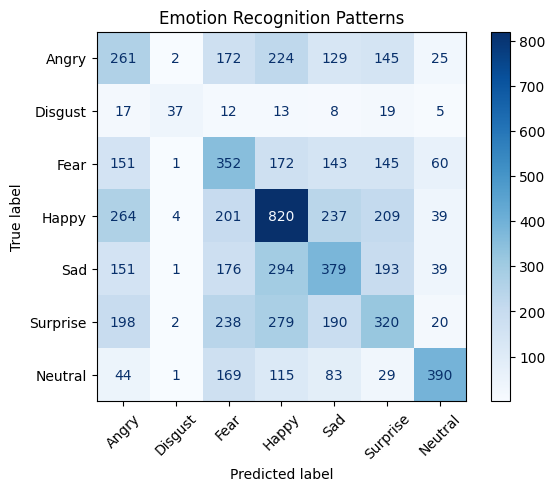

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Get predictions for the test set
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Define emotion labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# 3. Print Accuracy Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=emotion_labels))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Emotion Recognition Patterns")
plt.show()

In [7]:
import cv2
import numpy as np

# 1. Setup Camera and Face Detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv2.VideoCapture(0)

# Define labels to match your folder structure
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

print("Camera started. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret: break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        # Extract and resize the face
        roi_gray = gray[y:y+h, x:x+w]
        roi_gray = cv2.resize(roi_gray, (48, 48)) 
        
        # --- PREPROCESSING (Must match your training exactly) ---
        # 1. Flatten
        flattened_face = (roi_gray.flatten().reshape(1, -1) / 255.0)
        
        # 2. Standardize (Use the scaler object from Cell 2)
        # This fixes the 18% accuracy problem by centering the camera data
        scaled_face = scaler.transform(flattened_face) 
        
        # 3. PCA Transform (512 components)
        pca_face = pca.transform(scaled_face)
        
        # 4. Reshape (16x32 = 512)
        # This fixes your 'Matrix size-incompatible' error
        cnn_input = pca_face.reshape(-1, 16, 32, 1)

        # --- PREDICTION ---
        prediction = model.predict(cnn_input, verbose=0)
        max_index = np.argmax(prediction)
        emotion = emotion_labels[max_index]

        # --- VISUALIZATION ---
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, emotion, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow('Face Pattern Recognition', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Camera started. Press 'q' to quit.
